<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/DL/PyTorch_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import pandas as pd
print(torch.__version__)

2.6.0+cu124


##Introduction to Tensors
Creating tensors

In [2]:
# scalar
scalar = torch.tensor(7)
scalar

tensor(7)

In [3]:
scalar.ndim

0

In [4]:
# Get tensor back as python int
scalar.item()

7

In [5]:
# Vector
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [6]:
vector.ndim

1

In [7]:
vector.shape

torch.Size([2])

In [8]:
# MATRIX
MATRIX = torch.tensor([[7,8],
                       [9,10]])
MATRIX

tensor([[ 7,  8],
        [ 9, 10]])

In [9]:
MATRIX.ndim

2

In [10]:
MATRIX[1]

tensor([ 9, 10])

In [11]:
MATRIX.shape

torch.Size([2, 2])

In [12]:
# TENSOR
TENSOR = torch.tensor([[[1,2,3],
                        [4,5,6],
                        [7,8,9]]])
TENSOR

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

In [13]:
TENSOR.ndim

3

In [14]:
TENSOR.shape

torch.Size([1, 3, 3])

In [15]:
TENSOR[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

### ndim visualisation
### ndim basically tells us the number of *dimensions*

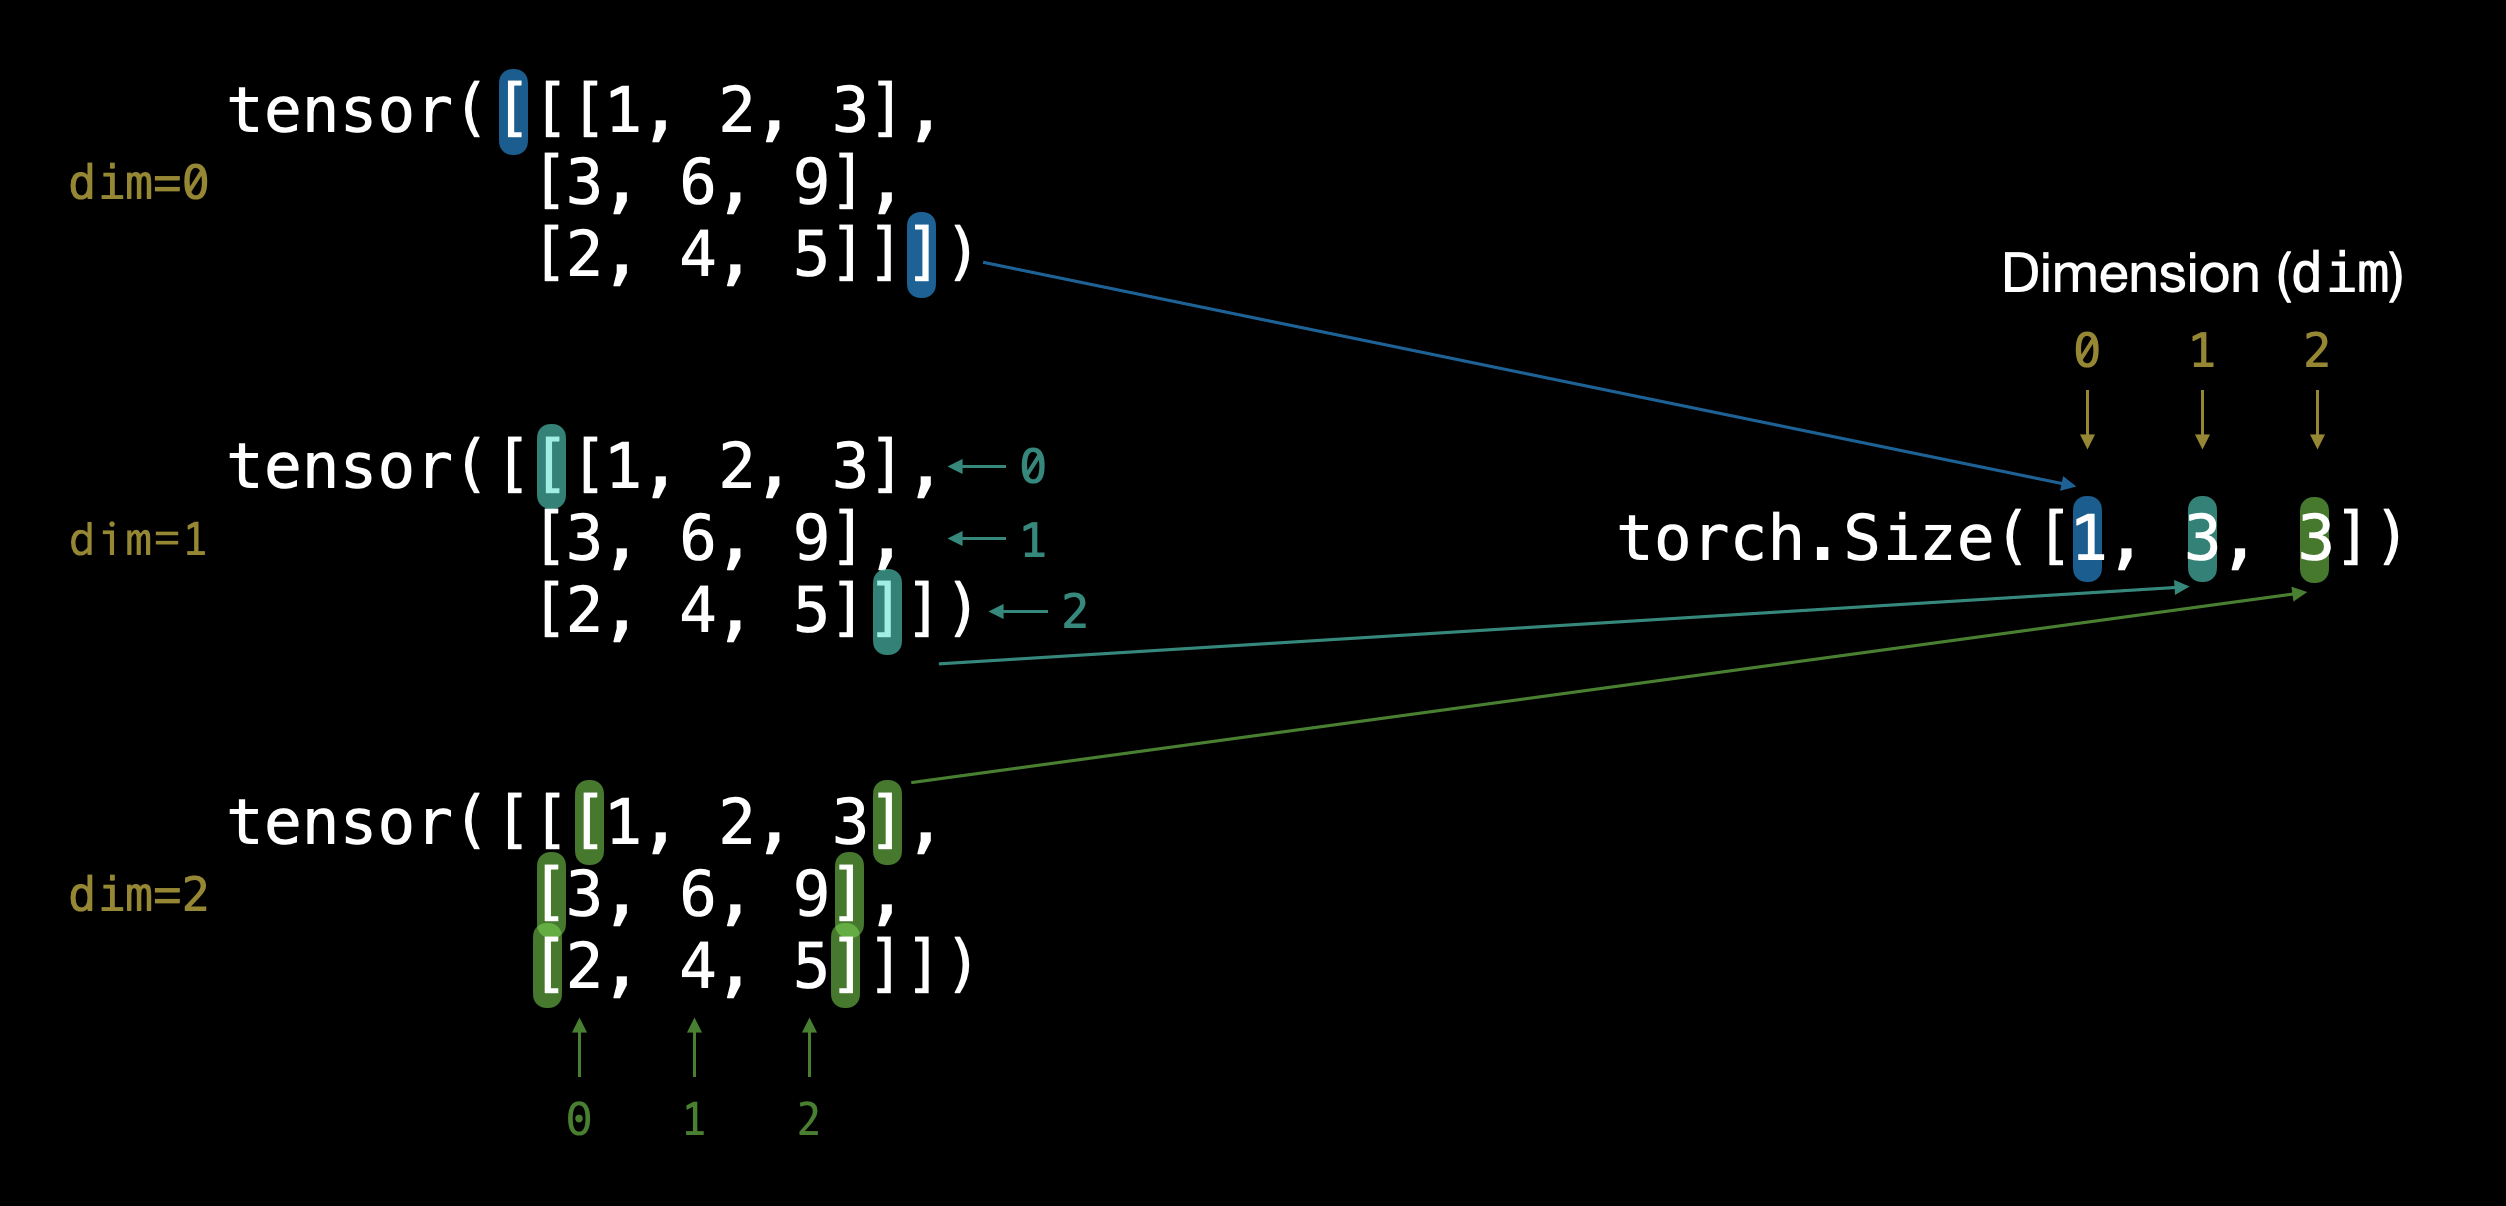

### Random tensors

random tensors are important because the way many neural networks learn is that they start with tensors full of random number and then adjust those random numbers and then adjust those random numbers to better represnt the data

`Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers`

In [16]:
# Create a random tensor of size (3, 4)
# we can either use torch.rand(size = (3, 4)) or torch.rand(3,4)
# random_tensor = torch.rand(3, 4)
random_tensor = torch.rand(size = (3, 4))
random_tensor

tensor([[0.6989, 0.8079, 0.3353, 0.1794],
        [0.2268, 0.2277, 0.8216, 0.9553],
        [0.7268, 0.9895, 0.2555, 0.6649]])

In [17]:
random_tensor.ndim

2

In [18]:
# Create a random tensor with similar shape to an image tensor
random_image_size_tensor = torch.rand(size = (224, 224, 3))  # height, width, color channels  (R, G, B)
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

### Zeros and ones

In [19]:
# Create a tensor of all zeros
zeros = torch.zeros(size = (3,4))
zeros

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [20]:
# Create a tensor of all ones
ones = torch.ones(size = (3, 4))
ones

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [21]:
ones.dtype, random_tensor.dtype, zeros.dtype

(torch.float32, torch.float32, torch.float32)

### Creating a range of tensors and tesnors-like

In [22]:
# Use torch.arange()
one_to_ten = torch.arange(start = 1, end = 11, step = 1)
one_to_ten

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [23]:
#Creating tensors like
ten_zeros = torch.zeros_like(input = one_to_ten)
ten_ones = torch.ones_like(input = one_to_ten)
ten_zeros, ten_ones

(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))

### Tensor datatypes

**Note:** Tensor datatypes is one of the 3 big errors you'll run into with PyTorch & deep learning:

1. Tensors not right datatype
2. Tensors not right shape
3. Tensors not on the right device

In [24]:
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype = None)
float_32_tensor

tensor([3., 6., 9.])

In [25]:
float_32_tensor.dtype # because default datatype in pytorch is float_32

torch.float32

In [26]:
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype = torch.float16)
float_16_tensor.dtype

torch.float16

In [27]:
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype = None, # what datatype is the tensor (e.g. float32 or float16)
                               device = None, # what device is your tensor on (e.g. cpu, gpu, cuda)
                               requires_grad=False) # wheter or not to track gradients with tensors operations
float_32_tensor

tensor([3., 6., 9.])

In [28]:
float_32_tensor.dtype

torch.float32

In [29]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [30]:
float_16_tensor * float_32_tensor

tensor([ 9., 36., 81.])

In [31]:
int_32_tensor = torch.tensor([3, 6, 9],
                             dtype=torch.int32)
int_32_tensor

tensor([3, 6, 9], dtype=torch.int32)

In [32]:
float_32_tensor * int_32_tensor

tensor([ 9., 36., 81.])

In [33]:
long_tensor = torch.tensor([3, 6, 9],
                           dtype = torch.long)
long_tensor, long_tensor.dtype

(tensor([3, 6, 9]), torch.int64)

### Getting information from tensors (tensor attributes)


1. Tensors not right datatype - to get datatype from a tensor, can use `tensor.dtype`
2. Tensors not right shape - to get shape from a tensor, can use `tensor.shape`
3. Tensors not on the right device - to get device from a tensor, can use `tensor.device`

In [34]:
# Create a tensor
some_tensor = torch.rand([3, 4],
                         dtype=torch.float16)
some_tensor

tensor([[0.7749, 0.6338, 0.0088, 0.4624],
        [0.6567, 0.2573, 0.8008, 0.3472],
        [0.1802, 0.1118, 0.7729, 0.5493]], dtype=torch.float16)

In [35]:
# Find out details about some tensor
print(some_tensor)
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Device of tensor: {some_tensor.device}")

tensor([[0.7749, 0.6338, 0.0088, 0.4624],
        [0.6567, 0.2573, 0.8008, 0.3472],
        [0.1802, 0.1118, 0.7729, 0.5493]], dtype=torch.float16)
Datatype of tensor: torch.float16
Shape of tensor: torch.Size([3, 4])
Device of tensor: cpu


### Manipulating Tensors (tensor operations)

Tensor operations include:
* Addition
* Subtraction
* Multiplication (element-wise)
* Division
* Matrix Multiplication

In [36]:
# Create a tensor and add 10 to it
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [37]:
# Multiply a tensor by 10
tensor * 10

tensor([10, 20, 30])

In [38]:
# Subtract a tensor by 10
tensor - 10

tensor([-9, -8, -7])

In [39]:
# Division a tensor by 10
tensor / 10

tensor([0.1000, 0.2000, 0.3000])

In [40]:
# Try out PyTorch in-built functions
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [41]:
torch.add(tensor, 10)

tensor([11, 12, 13])

### Matrix Multiplication
Two main ways of performing multiplication in Neural Networks and deep learning:

1. Element-wise multiplication
2. Matrix multiplication (dot product)

There are two main rules that performing matrix multiplication needs to satisfy:
1. The **inner dimensions** must match:
* `(3, 2) @ (3, 2)` won't work
* `(2, 3) @ (3, 2)` will work
* `(3, 2) @ (2, 3)` will work
2. The resulting matrix has the shape of the **outer dimensions**
* `(2, 3) @ (3, 2)` -> `(2, 2)`

In [42]:
# Element wise multiplication
print(tensor, "*", tensor)
print(f"Equals: {tensor * tensor}")

tensor([1, 2, 3]) * tensor([1, 2, 3])
Equals: tensor([1, 4, 9])


#### Dot Product (Matrix Mulitplication)
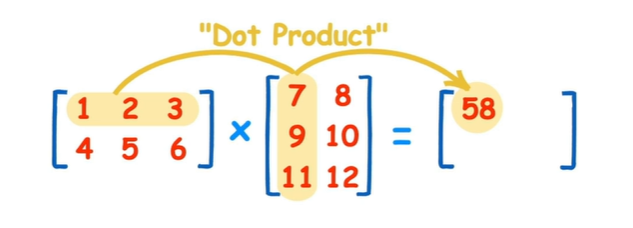

In [43]:
# Matrix multiplication
torch.matmul(tensor, tensor)

tensor(14)

In [44]:
# Matrix multiplication by hand
1*1 + 2*2 + 3*3

14

In [45]:
%%time
value = 0
for i in range(len(tensor)):
  value += tensor[i] + tensor[i]
print(value)

tensor(12)
CPU times: user 1.51 ms, sys: 90 µs, total: 1.6 ms
Wall time: 1.78 ms


In [46]:
%%time
torch.matmul(tensor, tensor)

CPU times: user 984 µs, sys: 0 ns, total: 984 µs
Wall time: 1.62 ms


tensor(14)

### One of the most common errors in deep learning is shape errors

In [47]:
# Shapes for matrix multiplication
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]])
tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]])

print(tensor_A.shape, tensor_B.shape)

torch.Size([3, 2]) torch.Size([3, 2])


To fix our tensor shape issues, we can manipulate the shape of one of our tensors using a **transpose**.
A **transpose** switches the axes or dimensions of a given tensor.

In [48]:
tensor_B, tensor_B.shape

(tensor([[ 7, 10],
         [ 8, 11],
         [ 9, 12]]),
 torch.Size([3, 2]))

In [49]:
#Transpose
tensor_B.T, tensor_B.T.shape

(tensor([[ 7,  8,  9],
         [10, 11, 12]]),
 torch.Size([2, 3]))

In [50]:
# The matrix multiplication operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}")
print(f"New shapes: tensor_A = {tensor_A.shape} (same shape as above), tensor_B.T = {tensor_B.T.shape}")
print(f"Multiplying: {tensor_A.shape} @ {tensor_B.T.shape} <- inner dimensions must match")
print("Output:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output)
print(f"\nOuput shape: {output.shape}")

Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])
New shapes: tensor_A = torch.Size([3, 2]) (same shape as above), tensor_B.T = torch.Size([2, 3])
Multiplying: torch.Size([3, 2]) @ torch.Size([2, 3]) <- inner dimensions must match
Output:

tensor([[ 27,  30,  33],
        [ 61,  68,  75],
        [ 95, 106, 117]])

Ouput shape: torch.Size([3, 3])


### Finding the min, max, sum, etc (tensor aggregation)

In [51]:
# Create a tensor
X = torch.arange(1, 100, 10)
X = X.type(torch.float32)
X

tensor([ 1., 11., 21., 31., 41., 51., 61., 71., 81., 91.])

In [52]:
# Find the min
torch.min(X), X.min()

(tensor(1.), tensor(1.))

In [53]:
# Find the max
torch.max(X), X.max()

(tensor(91.), tensor(91.))

In [54]:
# Find the mean - note: the torch.mean() requires a tensor of float32 datatype to work
torch.mean(X.type(torch.float32)), X.type(torch.float32).mean()

(tensor(46.), tensor(46.))

In [55]:
# Find the sum
torch.sum(X), X.sum()

(tensor(460.), tensor(460.))

### Finding the positional min and max

In [56]:
X

tensor([ 1., 11., 21., 31., 41., 51., 61., 71., 81., 91.])

In [57]:
# Find the position in tensor that has the minimum value with argmin() -> returns index position of target tensor where the minimum value occurs
X.argmin()

tensor(0)

In [58]:
X[0]

tensor(1.)

In [59]:
# Find the position in tensor that has the maximum value with argmax()
X.argmax()

tensor(9)

In [60]:
X[9]

tensor(91.)

### REshaping, stacking, squeezing and unsqueezing

* Reshaping - reshapes an input tensor to a defined shape
* View - return a view of an input tensor of certain shape but keep the same memory as the original tensor
* Stacking - combine multiple tensors on top of each other (vstack) or side by side (hstack)
* Squeeze - removes all `1` dimensions from a tensor
* Unsqueeze - add a `1` dimension to a target tensor
* Permute - Return a view of the input with dimensions permuted (swapped) in a certain way

In [61]:
# Create a tensor
X = torch.arange(1., 11.)
X, X.shape

(tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]), torch.Size([10]))

In [62]:
# Add an extra dimension
X_reshaped = X.reshape(10, 1)
X_reshaped, X_reshaped.shape

(tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.]]),
 torch.Size([10, 1]))

In [63]:
X_reshaped = X.reshape(5, 2)
X_reshaped, X_reshaped.shape

(tensor([[ 1.,  2.],
         [ 3.,  4.],
         [ 5.,  6.],
         [ 7.,  8.],
         [ 9., 10.]]),
 torch.Size([5, 2]))

In [71]:
# Change a tensor
X = torch.arange(1, 10)
X = X.type(torch.float32)
# Create a view
z = X.view(1, 9)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7., 8., 9.]]), torch.Size([1, 9]))

In [72]:
# Changing z changes x (because a view of a tensor shares the same memory as the original input)
z[:, 0] = 5
z, X

(tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]]),
 tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.]))

In [76]:
# Stack tensors on top of each other
X_stacked = torch.stack([X, X, X, X], dim = 1 )
X_stacked

tensor([[5., 5., 5., 5.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.],
        [4., 4., 4., 4.],
        [5., 5., 5., 5.],
        [6., 6., 6., 6.],
        [7., 7., 7., 7.],
        [8., 8., 8., 8.],
        [9., 9., 9., 9.]])

In [87]:
X_reshaped = X.reshape(1, 9)

In [88]:
# torch.squeeze() - removes all single dimensions from a target tesnor
print(f"Previous tensor: {X_reshaped}")
print(f"Previous shape: {X_reshaped.shape}")

# Remove extra dimensions from X_reshaped
X_squeezed = X_reshaped.squeeze()
print(f"\nNew tensor: {X_squeezed}")
print(f"New shape: {X_squeezed.shape}")

Previous tensor: tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])
Previous shape: torch.Size([1, 9])

New tensor: tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.])
New shape: torch.Size([9])


In [89]:
# torch.unsqueeze() - adds a single dimension to a target tensor at a specific dim
print(f"Previous target: {X_squeezed}")
print(f"Previous shape: {X_squeezed.shape}")

# Add an extra dimension with unsqueeze
X_unsqueezed = X_squeezed.unsqueeze(dim = 0)
print(f"\nNew tensor: {X_unsqueezed}")
print(f"New shape: {X_unsqueezed.shape}")

Previous target: tensor([5., 2., 3., 4., 5., 6., 7., 8., 9.])
Previous shape: torch.Size([9])

New tensor: tensor([[5., 2., 3., 4., 5., 6., 7., 8., 9.]])
New shape: torch.Size([1, 9])


In [90]:
# torch.permute - rearranges the dimensions of a target tensor in a specific order
X_original = torch.rand(size = (224, 224, 3)) # [height, width, color_channels]

# Permute the original tensor to rearrange the axis (or dim) order
X_permuted = X_original.permute(2, 0, 1) # shifts axis 0->1, 1->2, 2->0

print(f'Previous shape: {X_original.shape}')
print(f'New shape: {X_permuted.shape}') # [color_channels, height, width]

Previous shape: torch.Size([224, 224, 3])
New shape: torch.Size([3, 224, 224])


### Indexing (selecting data from tensors)

Indexing with PyTorch is similar to indexing with NumPY

In [97]:
# Create a tensor
X = torch.arange(1, 10).reshape(1, 3, 3)
X, X.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [98]:
# Let's index on our new tensor
X[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [99]:
# Let's index on the middle bracket (dim = 1)
X[0][0]

tensor([1, 2, 3])

In [100]:
# Let's index on the most inner bracket (last dimension)
X[0][0][0]

tensor(1)

In [101]:
# You can also use ":" to select "all" of a target dimension
X[:, 0]

tensor([[1, 2, 3]])

In [102]:
# Get all values of 0th and 1st dimension but only 1 of 2nd dimension
X[:, :, 1]

tensor([[2, 5, 8]])

In [103]:
# Get all values of the 0 dimension but only the 1 index value of 1st and 2nd dimension
X[:, 1, 1]

tensor([5])

In [104]:
# Get index 0 of 0th and 1st dimension and all values of 2nd dimension
X[0, 0, :]

tensor([1, 2, 3])

### PyTorch tensors & NumPy

NumPy is a popular scientific Python numerical computing torch.library.

And because of this, PyTorch has functionality to interact with it.

* Data in NumPy, wnat in PyTorch tensor -> `torch.from_numpy(ndarray)`
* PyTorch tensor -> NumPy -> `torch.Tensor.numpy()`


In [113]:
# NumPy array to tensor
import torch
import numpy as np

array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array) # warning: when converting from numpy -> pytorch, pytorch reflects numpy's default datatype of float64 unless specified otherwise
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [114]:
# Change the value of array, what will this do to `tensor`?
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [115]:
# Tensor to NumPy array
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [116]:
# Change the tensor, what happens to `numpy_tensor`?
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

### Reproducability (trying to take random out of random)

In short how a neural network learns:

`start with random numbers -> tensor operations -> update random numbers to try and make them better representations of the data -> again -> again -> again...`

To reduce the randomness in neural networks and PyTorch comes the concept of a **random seed**

Essentially what the random seed does is "flavour" the randomness

In [118]:
# Create two random tensors
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(random_tensor_A)
print(random_tensor_B)
print(random_tensor_A == random_tensor_B)

tensor([[0.8617, 0.0260, 0.3411, 0.7425],
        [0.6244, 0.2205, 0.4330, 0.5769],
        [0.5933, 0.1868, 0.4801, 0.1058]])
tensor([[0.9144, 0.0946, 0.5457, 0.4087],
        [0.8328, 0.2597, 0.9303, 0.1550],
        [0.4075, 0.8960, 0.1950, 0.0585]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [120]:
# Let's make some random but reproducable tensors
import torch

# Set the random seed
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

torch.manual_seed(RANDOM_SEED)
random_tensor_D = torch.rand(3, 4)

print(random_tensor_C)
print(random_tensor_D)
print(random_tensor_C == random_tensor_D)

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


## Running tensors and PyTorch objects on the GPUs (and making faster computations)
GPUs = faster computation on numbers, thanks to CUDA + NVIDIA hardware + PyTorch working behind the scenes to make everything hunky dory(good)

### 1. Getting a GPU

1. Easiest - Use Google Colab for a free GPU (options to upgrade as well)
2. Use your own GPU - takes a little bit of setup and requires the investment of purchasing a GPU, there's lots of options...,
3. Use cloud computing - GCP, AWS, Azure, these services allow you to rent computers on the cloud and access them

In [121]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### Check for GPU access with PyTorch

In [122]:
# Check for GPU access with PyTorch
import torch
torch.cuda.is_available()

False

In [123]:
# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [124]:
# Count number of devices
torch.cuda.device_count()

0

### 3. Putting tensors (and models) on the GPU
The reason we want our tensors/models on the GPU because using a GPU results in faster computations

In [125]:
#Create a tensor (default on the CPU)
tensor = torch.tensor([1, 2, 3], device = 'cpu')
print(tensor, tensor.device)

tensor([1, 2, 3]) cpu


In [126]:
# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3])

### 4. Moving tensors back to the CPU

In [129]:
# If tensor is on GPU, can't transform it to NumPy
tensor_on_gpu.numpy()

array([1, 2, 3])

In [130]:
#To fix the GPU tensor with NumPy issue, we can first set it to the CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

array([1, 2, 3])

In [131]:
tensor_on_gpu

tensor([1, 2, 3])